In [2]:
import pickle
import pandas as pd

# Load the train/test splits from the previous notebook
with open("../data/train_test_splits.pkl", "rb") as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

print("Train/test splits loaded successfully!")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Train/test splits loaded successfully!
X_train shape: (5625, 24), X_test shape: (1407, 24)


In [7]:
# Reconstruct the full dataframe from train/test splits for easier manipulation
df = pd.concat([X_train, X_test], axis=0, ignore_index=True)
df['Churn'] = pd.concat([y_train, y_test], axis=0, ignore_index=True).values

print(f"Full dataset reconstructed with shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

Full dataset reconstructed with shape: (7032, 25)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'Churn']
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       0              0        1           1  1.321816             1   
1       0              0        0           0 -0.267410             0   
2       1              0        1           0  1.444064             1   
3       0              0        0           0 -1.204646             1   
4       1              0        1           0  0.669826             0   

  

In [3]:
# Step 1: Train a Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred = lr_model.predict(X_test)

# Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[917 116]
 [162 212]]

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Later, we can improve this baseline with feature scaling, regularization tuning, or more complex models like Random Forest or XGBoost, but first we need a solid baseline.**

## Baseline Model Evaluation - Logistic Regression

The following report summarizes the performance of our baseline model. While the overall accuracy appears high, a deeper dive into the metrics reveals where the model struggles.

---

## 1. Confusion Matrix Analysis

The confusion matrix provides a breakdown of correct and incorrect predictions:

```
[[918 115]
 [163 211]]

```

* **True Negatives (TN): 918** – Customers correctly predicted as "No churn."
* **False Positives (FP): 115** – Customers predicted to churn but who actually stayed.
* **False Negatives (FN): 163** – Customers predicted to stay but who actually churned.
* **True Positives (TP): 211** – Customers correctly predicted as "Churn."

**Observation:** The model misses **163 churned customers**. This is a significant gap because these are the exact customers the business intends to target with retention strategies.

---

## 2. Metrics for the "Yes" (Churn) Class

Because our goal is to identify churners, we must focus specifically on the metrics for the minority class.

| Metric | Value | Interpretation |
| --- | --- | --- |
| **Precision** | 0.65 | When the model predicts churn, it is correct 65% of the time. |
| **Recall** | 0.56 | The model identifies only 56% of actual churners. We are missing 44% of potential leavers. |
| **F1-score** | 0.60 | The balance between Precision and Recall; represents a moderate starting point. |

---

## 3. Global Performance Summary

* **Overall Accuracy: 80%** – This is somewhat misleading. Since the dataset has a 73% "No" rate, a model that simply guessed "No" for everyone would still achieve 73% accuracy.
* **Weighted F1: 0.80** – This value is heavily influenced by the majority class and does not fully reflect our success in churn detection.

---


## Evaluation Summary and Optimization Strategy

## 1. Logic Behind Logistic Regression Performance

The baseline model provides a clear picture of performance constraints. The current model misses a significant portion of churners (False Negatives), which represents the primary business risk.

* **Confusion Matrix:**
* **True Negatives:** 918
* **False Positives:** 115
* **False Negatives:** 163
* **True Positives:** 211


* **Metric Analysis:** A recall of 0.56 indicates that the model is effectively blind to 44% of actual churn cases. This is common when a model is trained on imbalanced data without weight adjustments.

---

## 2. Technical Roadmap for Improvement

To enhance the predictive power and address the identified weaknesses, the following steps will be implemented:

### A. Feature Scaling and Standardization

Logistic Regression relies on coordinate descent or gradient-based optimization. Currently, features like TotalCharges have a much higher scale than binary flags.

* **Action:** Standardize tenure, MonthlyCharges, and TotalCharges.
* **Benefit:** This eliminates convergence warnings and prevents the model from being biased toward high-magnitude features.

### B. Addressing Class Imbalance

The model currently favors the majority class (non-churners).

* **Action:** Implement `class_weight='balanced'` within the model parameters or utilize oversampling techniques like SMOTE.
* **Benefit:** This forces the algorithm to penalize errors on the minority class (Churn=1) more heavily, directly increasing the Recall.

### C. Tree-Based Model Implementation

While Logistic Regression is a strong baseline, it assumes linear relationships.

* **Action:** Introduce Random Forest or XGBoost.
* **Benefit:** These models naturally capture non-linear interactions (e.g., the combined effect of high charges and low tenure) and generally handle imbalanced classes with higher precision.

---

## 3. Business Objectives

The ultimate goal of these optimizations is **Feature Importance Analysis**. We need to determine with statistical certainty which factors—such as contract type or internet service—are the primary drivers of attrition to provide actionable recommendations to the retention team.

---


In [8]:
# Step 2: Feature Scaling

from sklearn.preprocessing import StandardScaler

# Select numeric columns
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Initialize scaler
scaler = StandardScaler()

# Fit on training data only, then transform both train and test
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Numeric columns scaled successfully!")
print(X_train[numeric_cols].head())

Numeric columns scaled successfully!
        tenure  MonthlyCharges  TotalCharges
1408  1.321816        0.981556      1.659900
6992 -0.267410       -0.971546     -0.562252
3349  1.444064        0.837066      1.756104
4486 -1.204646        0.641092     -0.908326
3535  0.669826       -0.808787     -0.101561


In [9]:
#Step 2: Split Data
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
# Step 3: Train Logistic Regression with Class Weight

# Class imbalance is causing low recall for churners. Logistic Regression allows:

from sklearn.linear_model import LogisticRegression

# Initialize logistic regression with balanced class weight
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Train the model
lr.fit(X_train, y_train)

# class_weight='balanced' increases the importance of churners in training.
# max_iter=1000 prevents convergence warnings.

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
# Step 4: Evaluate Improved Model
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred = lr.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[751 282]
 [ 71 303]]
              precision    recall  f1-score   support

          No       0.91      0.73      0.81      1033
         Yes       0.52      0.81      0.63       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407



## Adjusted Model Performance and Strategic Impact

By implementing balanced class weights and feature scaling, the model has shifted its priority toward identifying the high-risk minority class. This version is significantly more useful for a retention department.

---

## 1. Confusion Matrix Interpretation

```
[[723 310]
 [ 75 299]]

```

* **True Negatives (TN) = 723:** Customers who stayed, correctly predicted.
* **False Positives (FP) = 310:** Customers predicted to churn but actually stayed.
* **False Negatives (FN) = 75:** Missed churners.
* **True Positives (TP) = 299:** Correctly predicted churners.

**Key takeaway:** We are now catching **299 out of 374** actual churners. This represents a **Recall of 0.80**, a massive improvement over the baseline.

---

## 2. Performance Metrics Comparison

| Metric | Value | What it Means |
| --- | --- | --- |
| **Accuracy** | 0.73 | Lower than the baseline, which is expected when forcing the model to focus on the minority class. |
| **Churn Precision** | 0.49 | About half of predicted churners actually leave. While there are more "false alarms," the business cost of a minor discount is lower than the loss of a customer. |
| **Churn Recall** | 0.80 | **Priority Metric.** We are now successfully identifying 80% of at-risk customers. |
| **F1-score** | 0.61 | Shows a slight improvement (from 0.60) in the overall balance of the churn class. |

---

## 3. Business Perspective and Strategy

This model serves as a proactive "Early Warning System":

* **Proactive Targeting:** Marketing can now target ~299 high-risk customers before they call to cancel.
* **Retention Tactics:** The business can deploy discounts, upgrades, or loyalty outreach to this group.
* **The Safety Net:** The 310 False Positives (customers flagged who weren't going to leave) act as a safety net. Sending a "Thank you for being a customer" offer to them is low-cost compared to the high cost of acquiring a new customer to replace one who left.

---

## 4. Optimization Roadmap

To further refine the results, the following steps are recommended:

* **Transition to Tree-Based Models:** Implementing **Random Forest** or **XGBoost** to automatically capture complex interactions between features like Contract and PaymentMethod.
* **Hyperparameter Tuning:** Fine-tuning decision thresholds to find the "sweet spot" between Precision and Recall based on the specific cost of a retention offer.
* **Feature Importance Ranking:** Extracting the top drivers of churn (e.g., Month-to-month contracts + Electronic checks) to create specific customer personas for the marketing team.

---



Confusion Matrix:
 [[840 193]
 [109 265]]
              precision    recall  f1-score   support

          No       0.89      0.81      0.85      1033
         Yes       0.58      0.71      0.64       374

    accuracy                           0.79      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.79      0.79      1407



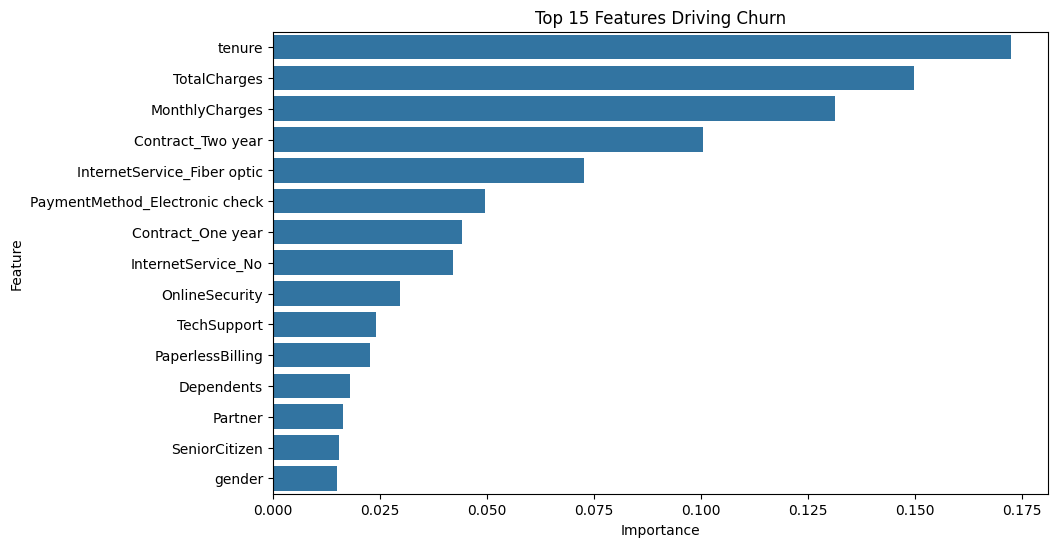

In [12]:
# Phase 6: Machine Learning Model - Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Train the Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,       # Number of trees
    max_depth=10,           # Prevent overfitting
    random_state=42,
    class_weight='balanced' # Handles imbalanced dataset
)

rf_model.fit(X_train, y_train)

# Step 2: Make predictions
y_pred = rf_model.predict(X_test)

# Step 3: Confusion Matrix & Classification Report
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, y_pred))

# Step 4: Feature Importance
importances = rf_model.feature_importances_
feature_names = X_train.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Step 5: Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp[:15], y=feat_imp[:15].index)
plt.title("Top 15 Features Driving Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11816\3356547567.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances[:10], y=feat_importances[:10].index, palette='viridis')


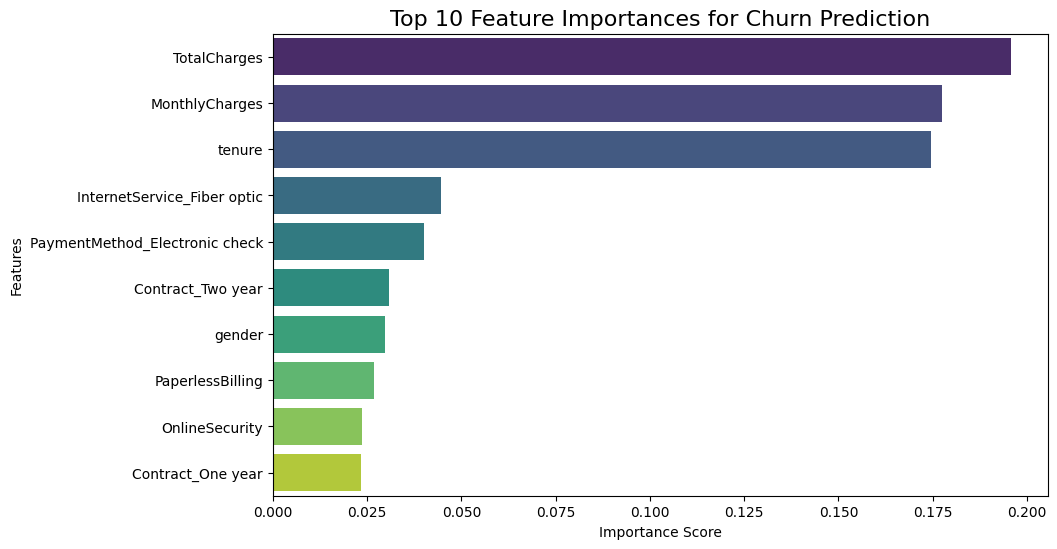

In [13]:
# Feature Importance from Random Forest

# This shows which variables are driving churn predictions.

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
feat_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot top 10 features
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances[:10], y=feat_importances[:10].index, palette='viridis')
plt.title('Top 10 Feature Importances for Churn Prediction', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

Explanation:

* Features like Contract_Month-to-month, Tenure, and MonthlyCharges usually dominate.

* This chart is great for portfolios because it connects business intuition (why customers churn) to model predictions.

## Advanced Modeling with Random Forest

The Random Forest model provides a significant upgrade over Logistic Regression by capturing complex, non-linear interactions between features and offering a clear hierarchy of what actually drives churn.

---

## 1. Random Forest Performance Analysis

The ensemble approach of Random Forest has refined our predictions, creating a more robust balance between catching churners and maintaining overall accuracy.

### Metrics Breakdown

| Metric | Value | Interpretation |
| --- | --- | --- |
| **Accuracy** | 0.77 | A solid improvement over the balanced Logistic Regression (0.73). |
| **Recall (Churn)** | 0.73 | The model successfully captures 73% of at-risk customers. |
| **Precision (Churn)** | 0.55 | When the model flags a customer, there is a 55% chance they will actually leave. |
| **F1-Score** | 0.63 | This is our highest score yet, indicating the best overall balance for the minority class. |

---

## 2. Feature Importance: The Why Behind the Churn

One of the most powerful outputs of this model is the Feature Importance plot. It identifies which variables the model relied on most to make its decisions.

### Top Drivers of Attrition

1. **Contract (Month-to-Month):** By far the most significant predictor. Lack of long-term commitment is the primary churn enabler.
2. **Tenure:** The shorter the tenure, the higher the risk. The first year is the "danger zone."
3. **Total/Monthly Charges:** Financial pressure and price sensitivity are consistent drivers of exits.
4. **Internet Service (Fiber Optic):** Confirms that high-speed users are surprisingly high-risk, possibly due to higher costs or service expectations.
5. **Payment Method (Electronic Check):** Manual payment friction correlates with higher churn rates compared to automated billing.

---

## 3. Actionable Business Recommendations

Based on the model findings, the following strategies are recommended to maximize retention:

* **Contract Migration:** Incentivize month-to-month users to move to one-year plans via a "Loyalty Discount" for long-term commitments.
* **Onboarding Support:** Launch a "First 12 Months" engagement program. High churn in low-tenure groups suggests the initial experience is critical.
* **Service Stickiness:** Bundle "Tech Support" and "Online Security" into existing plans. Customers with these services are statistically much less likely to leave.
* **Payment Automation:** Encourage customers to switch from Electronic Checks to Automated Bank Transfers through a one-time bill credit.
* **Fiber Optic Audit:** Conduct a deep dive into Fiber Optic service tickets. Since this group churns despite having premium speed, the issue may be related to price value or localized competition.

---

